In [1]:
import numpy as np
import xarray as xr
from numba import njit, prange
from numba_progress import ProgressBar
from pathlib import Path
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from scipy import stats
import verde as vd

In [7]:
@njit(parallel=True)
def block_reduce_jit(xbin_edges, ybin_edges, coords, value, progress_proxy=None, metrics=['mean'], quantiles=None):

    dx = np.abs(xbin_edges[1]-xbin_edges[0])
    dy = np.abs(ybin_edges[1]-ybin_edges[0])
    x_center = xbin_edges[:-1]+dx/2
    y_center = ybin_edges[:-1]+dy/2

    shp = (y_center.size, x_center.size)

    if quantiles is None:
        result = np.full((len(metrics), *shp), np.nan)
    else:
        result = np.full((len(metrics)+len(quantiles), *shp), np.nan)

    xbin_inds = np.digitize(coords[0], xbin_edges)-1
    ybin_inds = np.digitize(coords[1], ybin_edges)-1

    bins = np.stack((xbin_inds.flatten(), ybin_inds.flatten())).T
    
    xb_uniq = np.unique(bins[:,0])
    yb_uniq = np.unique(bins[:,1])

    update_progressbar = progress_proxy is not None
    
    for i in prange(xb_uniq.size):
        xbin = xb_uniq[i]
        if xbin==x_center.size:
            continue
        inds1 = bins[:,0]==xbin
        bins1 = bins[inds1,:]
        value1 = value[inds1]
        for j in range(yb_uniq.size):
            ybin = yb_uniq[j]
            if ybin==y_center.size:
                continue
            inds2 = bins1[:,1]==ybin
            value2 = value1[inds2]
            
            count = value2.size
            if count > 0:
                for k, metric in enumerate(metrics):
                    if metric == 'count':
                        result[k,ybin,xbin] = count
                    elif metric == 'mean':
                        result[k,ybin,xbin] = np.nanmean(value2)
                    elif metric == 'median':
                        result[k,ybin,xbin] = np.nanmedian(value2)
                    elif metric == 'std':
                        result[k,ybin,xbin] = np.nanstd(value2)
                    elif metric == 'var':
                        result[k,ybin,xbin] = np.nanvar(value2)
                    elif metric == 'skew':
                        result[k,ybin,xbin] = np.nanmean((value2-np.nanmean(value2))**3) / np.nanmean((value2-np.nanmean(value2))**2)**1.5
                    elif metric == 'kurtosis':
                        result[k,ybin,xbin] = np.nanmean(((value2 - np.nanmean(value2)) / np.nanstd(value2))**4) - 3
                if quantiles is not None:
                    for k, q in enumerate(quantiles):
                        result[k+len(quantiles),ybin,xbin] = np.nanquantile(value2, q)

        if update_progressbar:
            progress_proxy.update(1)
        
    return result, (x_center, y_center)

def block_reduce(xbin_edges, ybin_edges, coords, value, metrics=[np.mean], quantiles=None):
    dx = np.abs(xbin_edges[1]-xbin_edges[0])
    dy = np.abs(ybin_edges[1]-ybin_edges[0])
    x_center = xbin_edges[:-1]+dx/2
    y_center = ybin_edges[:-1]+dy/2

    shp = (y_center.size, x_center.size)
    # print(shp)

    if quantiles is None:
        result = np.full((len(metrics), *shp), np.nan)
    else:
        result = np.full((len(metrics)+len(quantiles), *shp), np.nan)

    xbin_inds = np.digitize(coords[0], xbin_edges)-1
    ybin_inds = np.digitize(coords[1], ybin_edges)-1

    bins = np.stack((xbin_inds.flatten(), ybin_inds.flatten())).T
    
    xb_uniq = np.unique(bins[:,0])
    yb_uniq = np.unique(bins[:,1])
    
    for i in tqdm(range(xb_uniq.size)):
        xbin = xb_uniq[i]
        if xbin==x_center.size:
            continue
        inds1 = bins[:,0]==xbin
        bins1 = bins[inds1,:]
        value1 = value[inds1]
        for j in range(yb_uniq.size):
            ybin = yb_uniq[j]
            if ybin==y_center.size:
                continue
            inds2 = bins1[:,1]==ybin
            value2 = value1[inds2]
            
            count = value2.size
            if count > 0:
                for k, metric in enumerate(metrics):
                    result[k,ybin,xbin] = metric(value2)
                if quantiles is not None:
                    for k, q in enumerate(quantiles):
                        result[k+len(quantiles),ybin,xbin] = np.nanquantile(value2, q)

    # result = vd.make_xarray_grid(coordinates=(x_center, y_center), 
        
    return result, (x_center, y_center)

In [26]:
def general_block_reduce(xbin_edges, ybin_edges, coords, value, progress_bar=None, metrics=['mean'], quantiles=None, parallel=False):
    dx = np.abs(xbin_edges[1]-xbin_edges[0])
    dy = np.abs(ybin_edges[1]-ybin_edges[0])
    x_center = xbin_edges[:-1]+dx/2
    y_center = ybin_edges[:-1]+dy/2

    shape = (y_center.size, x_center.size)

    if quantiles is None:
        result = np.full((len(metrics), *shape), np.nan)
    else:
        result = np.full((len(metrics)+len(quantiles), *shape), np.nan)

    xbin_inds = np.digitize(coords[0], xbin_edges)-1
    ybin_inds = np.digitize(coords[1], ybin_edges)-1

    bins = np.stack((xbin_inds.flatten(), ybin_inds.flatten())).T

    if parallel==True:
        if progress_bar==True:
            with ProgressBar(total=xbin_edges.size-1) as progress:
                result = stat2d_par(shape, bins, value, result, metrics=metrics, quantiles=quantiles, progress_proxy=progress)
        else:
            result = stat2d_par(shape, bins, value, result, metrics=metrics, quantiles=quantiles, progress_proxy=None)
    else:
        result = stat2d(shape, bins, value, result, metrics=metrics, quantiles=quantiles, progress_bar=progress_bar)

    result = vd.make_xarray_grid(
        coordinates=(x_center, y_center),
        data=tuple(result[i] for i in range(result.shape[0])),
        data_names=([f'metric_{i}' for i in range(len(metrics))] + [f'q_{q}' for q in quantiles]),
        dims=('y', 'x')
    )

    return result

def stat2d(shape, bins, value, result, metrics=[np.mean], quantiles=None, progress_bar=True):
    
    xb_uniq = np.unique(bins[:,0])
    yb_uniq = np.unique(bins[:,1])

    pbar = tqdm(range(xb_uniq.size), disable= not progress_bar)
    for i in pbar:
        xbin = xb_uniq[i]
        if xbin==x_center.size:
            continue
        inds1 = bins[:,0]==xbin
        bins1 = bins[inds1,:]
        value1 = value[inds1]
        for j in range(yb_uniq.size):
            ybin = yb_uniq[j]
            if ybin==y_center.size:
                continue
            inds2 = bins1[:,1]==ybin
            value2 = value1[inds2]
            
            count = value2.size
            if count > 0:
                for k, metric in enumerate(metrics):
                    result[k,ybin,xbin] = metric(value2)
                if quantiles is not None:
                    for k, q in enumerate(quantiles):
                        result[k+len(quantiles),ybin,xbin] = np.nanquantile(value2, q)
        
    return result

@njit(parallel=True)
def stat2d_par(shape, bins, value, result, progress_proxy=None, metrics=['mean'], quantiles=None):

    xb_uniq = np.unique(bins[:,0])
    yb_uniq = np.unique(bins[:,1])

    update_progressbar = progress_proxy is not None
    for i in prange(xb_uniq.size):
        xbin = xb_uniq[i]
        if xbin==x_center.size:
            continue
        inds1 = bins[:,0]==xbin
        bins1 = bins[inds1,:]
        value1 = value[inds1]
        for j in range(yb_uniq.size):
            ybin = yb_uniq[j]
            if ybin==y_center.size:
                continue
            inds2 = bins1[:,1]==ybin
            value2 = value1[inds2]
            
            count = value2.size
            if count > 0:
                for k, metric in enumerate(metrics):
                    if metric == 'count':
                        result[k,ybin,xbin] = count
                    elif metric == 'mean':
                        result[k,ybin,xbin] = np.nanmean(value2)
                    elif metric == 'median':
                        result[k,ybin,xbin] = np.nanmedian(value2)
                    elif metric == 'std':
                        result[k,ybin,xbin] = np.nanstd(value2)
                    elif metric == 'var':
                        result[k,ybin,xbin] = np.nanvar(value2)
                    elif metric == 'skew':
                        result[k,ybin,xbin] = np.nanmean((value2-np.nanmean(value2))**3) / np.nanmean((value2-np.nanmean(value2))**2)**1.5
                    elif metric == 'kurtosis':
                        result[k,ybin,xbin] = np.nanmean(((value2 - np.nanmean(value2)) / np.nanstd(value2))**4) - 3
                if quantiles is not None:
                    for k, q in enumerate(quantiles):
                        result[k+len(quantiles),ybin,xbin] = np.nanquantile(value2, q)

        if update_progressbar:
            progress_proxy.update(1)
        
    return result

In [9]:
ds = xr.open_dataset(Path('D:/bedmachine/BedMachineAntarctica-v3.nc'))

xmin = -1e6
xmax = 0
ymin = -0.8e6
ymax = 0.2e6

ds = ds.sel(x=slice(xmin, xmax), y=slice(ymax, ymin))

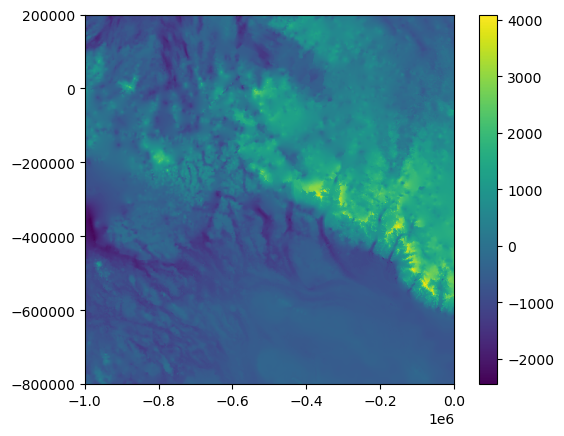

In [10]:
plt.pcolormesh(ds.x, ds.y, ds.bed)
plt.axis('scaled')
plt.colorbar()
plt.show()

In [11]:
xbin_edges = np.arange(xmin, xmax+5e3, 5e3)
ybin_edges = np.arange(ymin, ymax+5e3, 5e3)

xx, yy = np.meshgrid(ds.x, ds.y)
coords = (xx.flatten(), yy.flatten())
bed = ds.bed.values.flatten()

In [27]:
# result, center_coords = block_reduce(xbin_edges, ybin_edges, coords, bed, metrics=[np.mean, np.std], quantiles=[0.05, 0.95])
result = general_block_reduce(xbin_edges, ybin_edges, coords, bed, metrics=[np.mean, np.std], quantiles=[0.05, 0.95], parallel=False, progress_bar=True)
# x_center = center_coords[0]
# y_center = center_coords[1]
# result.shape, x_center.shape

  0%|          | 0/201 [00:00<?, ?it/s]

In [117]:
metrics=[np.mean, np.std]
quantiles=[0.05, 0.95]
[f'metric_{i}' for i in range(len(metrics))] + [f'q_{q}' for q in quantiles]

['metric_0', 'metric_1', 'q_0.05', 'q_0.95']

In [125]:
result

<xarray.Dataset> Size: 1MB
Dimensions:   (y: 200, x: 200)
Coordinates:
  * x         (x) float64 2kB -9.975e+05 -9.925e+05 ... -7.5e+03 -2.5e+03
  * y         (y) float64 2kB -7.975e+05 -7.925e+05 ... 1.925e+05 1.975e+05
Data variables:
    metric_0  (y, x) float64 320kB -1.109e+03 -1.109e+03 ... -1.42e+03
    metric_1  (y, x) float64 320kB 0.0 0.2766 1.322 ... 6.609 4.707 0.0001221
    q_0.05    (y, x) float64 320kB -1.109e+03 -1.11e+03 ... -1.429e+03 -1.42e+03
    q_0.95    (y, x) float64 320kB -1.109e+03 -1.109e+03 ... -1.42e+03 -1.42e+03

In [127]:
result.var_names()

AttributeError: 'Dataset' object has no attribute 'var_names'

In [14]:
dx = np.abs(xbin_edges[1]-xbin_edges[0])
dy = np.abs(ybin_edges[1]-ybin_edges[0])
x_center = xbin_edges[:-1]+dx/2
y_center = ybin_edges[:-1]+dy/2

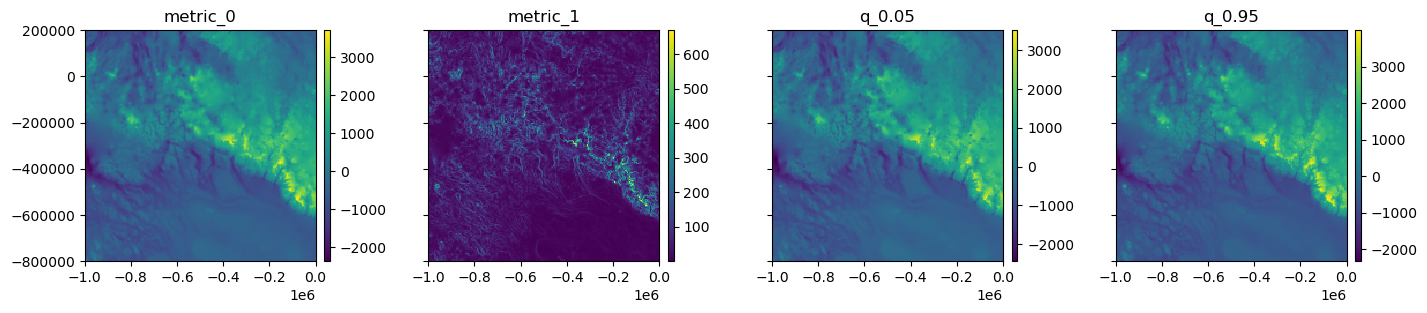

In [28]:
fig, axs = plt.subplots(1, 4, figsize=(17,3), sharey=True)
for i, (ax, name) in enumerate(zip(axs, list(result.keys()))):
    im = ax.pcolormesh(result.x, result.y, result[name])
    ax.axis('scaled')
    ax.set_title(name)
    plt.colorbar(im, ax=ax, pad=0.03, aspect=40)
plt.show()

# fig, axs = plt.subplots(1, 4, figsize=(17,3), sharey=True)
# for i, ax in enumerate(axs):
#     im = ax.pcolormesh(x_center, y_center, result[i])
#     ax.axis('scaled')
#     # ax.set_title(name)
#     plt.colorbar(im, ax=ax, pad=0.03, aspect=40)
# plt.show()

# JIT version

In [15]:
with ProgressBar(total=xbin_edges.size-1) as progress:
    result, center_coords = block_reduce_jit(xbin_edges, ybin_edges, coords, bed, progress, metrics=['mean', 'std'], quantiles=[0.05, 0.95])

  0%|          | 0/1000 [00:00<?, ?it/s]

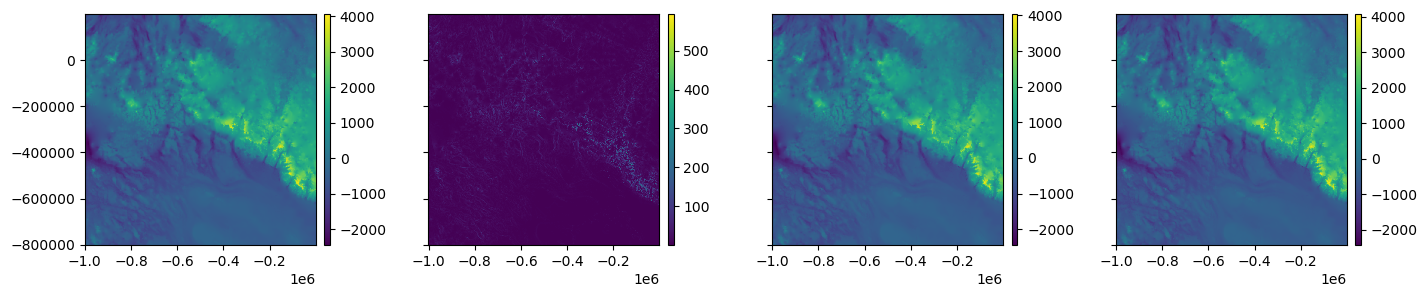

In [16]:
fig, axs = plt.subplots(1, 4, figsize=(17,3), sharey=True)
for i, ax in enumerate(axs):
    im = ax.pcolormesh(x_center, y_center, result[i])
    ax.axis('scaled')
    plt.colorbar(im, ax=ax, pad=0.03, aspect=40)
plt.show()

In [17]:
metrics = ['count', 'mean', 'median', 'std', 'skew', 'kurtosis']

with ProgressBar(total=xbin_edges.size-1) as progress:
    result, center_coords = block_reduce_jit(xbin_edges, ybin_edges, coords, bed, progress, metrics=metrics)

  0%|          | 0/1000 [00:00<?, ?it/s]

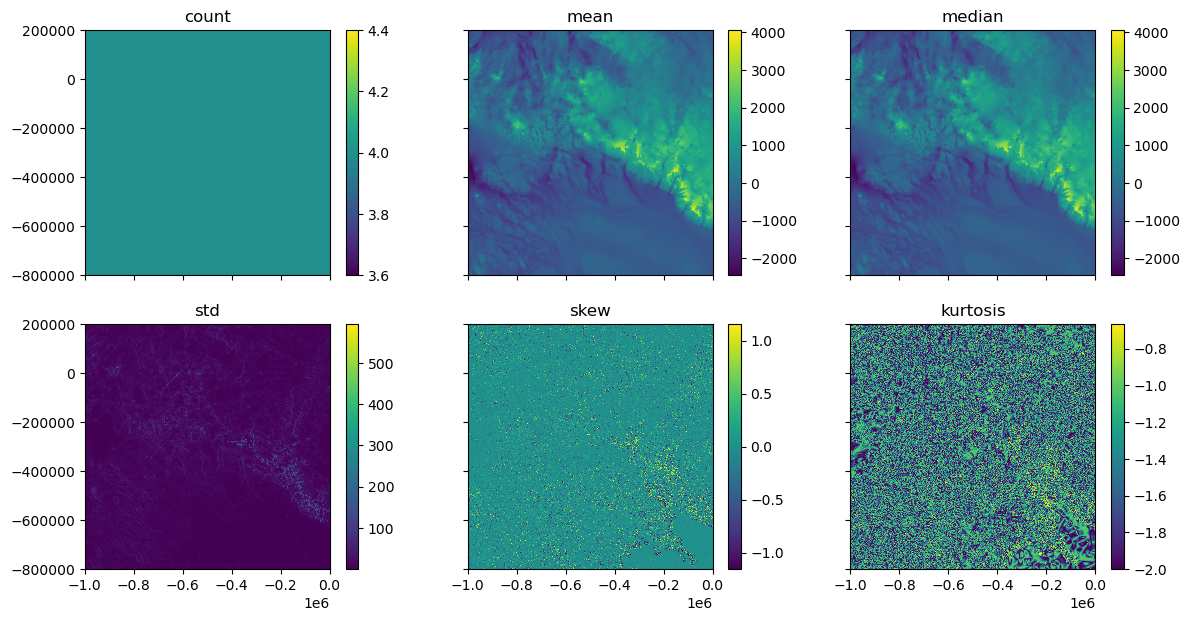

In [18]:
fig, axs = plt.subplots(2, 3, figsize=(14,7), sharey=True, sharex=True)

for i, (ax, metric) in enumerate(zip(axs.flatten(), metrics)):
    im = ax.pcolormesh(xbin_edges, ybin_edges, result[i,...])
    ax.axis('scaled')
    ax.set_title(metric)
    plt.colorbar(im, ax=ax)

plt.show()

In [20]:
import verde as vd

data = vd.datasets.fetch_baja_bathymetry()
data

,longitude,latitude,bathymetry_m
0,245.00891,27.49555,-636.0
1,245.01201,27.49286,-655.0
2,245.01512,27.49016,-710.0
3,245.01822,27.48746,-695.0
4,245.02443,27.48206,-747.0
...,...,...,...
82965,245.01511,24.60702,-3823.0
82966,245.01370,24.60910,-3828.0
82967,245.01026,24.61271,-3832.0
82968,245.00681,24.61633,-3852.0


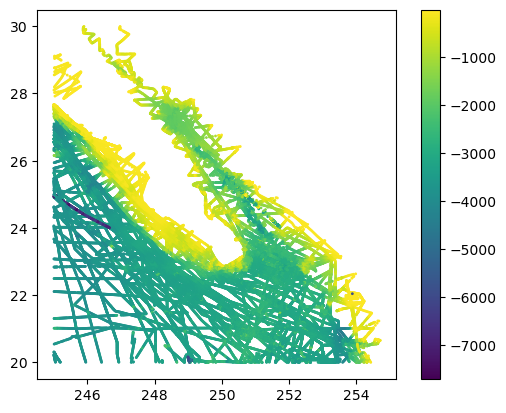

In [23]:
plt.scatter(data.longitude, data.latitude, c=data.bathymetry_m, s=1)
plt.axis('scaled')
plt.colorbar()
plt.show()

In [69]:
region = [np.min(data.longitude.values), np.max(data.longitude.values), np.min(data.latitude.values), np.max(data.latitude.values)]

coords_edges = vd.grid_coordinates(region=region, spacing=0.05, adjust='region')

In [70]:
xbin_edges = np.unique(coords_edges[0])
ybin_edges = np.unique(coords_edges[1])

coords = (data.longitude.values, data.latitude.values)

result, center_coords = block_reduce(xbin_edges, ybin_edges, coords, data.bathymetry_m.values, metrics=[np.mean, np.std])

  0%|          | 0/195 [00:00<?, ?it/s]

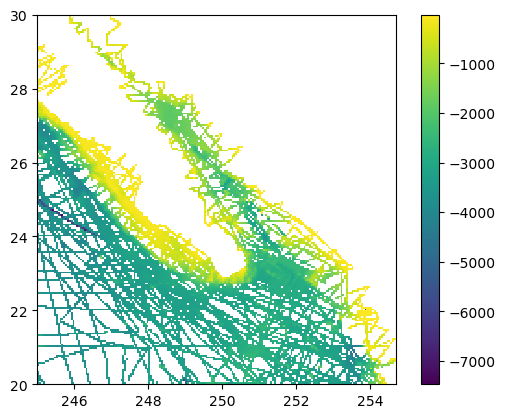

In [71]:
plt.pcolormesh(center_coords[0], center_coords[1], result[0])
plt.axis('scaled')
plt.colorbar()
plt.show()

In [75]:
# %%time

reducer = vd.BlockReduce(np.mean, spacing=0.05, region=region, adjust='region')
red_coords, red_data = reducer.filter(coords, data.bathymetry_m.values)

C:\Users\mjfie\mambaforge\envs\cryo\lib\site-packages\verde\blockreduce.py:179: FutureWarning: The provided callable <function mean at 0x0000028C9E680310> is currently using DataFrameGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  blocked = pd.DataFrame(columns).groupby("block").aggregate(reduction)
C:\Users\mjfie\mambaforge\envs\cryo\lib\site-packages\verde\blockreduce.py:236: FutureWarning: The provided callable <function mean at 0x0000028C9E680310> is currently using DataFrameGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  grouped = table.groupby("block").aggregate(self.reduction)


In [77]:
red_coords[0].shape

(12339,)

ValueError: not enough values to unpack (expected 2, got 1)

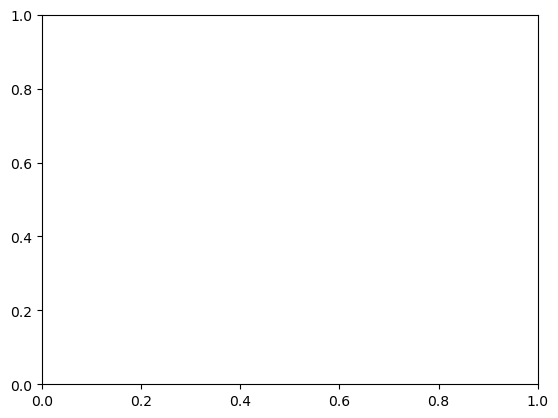

In [76]:
plt.pcolormesh(red_coords[0], red_coords[1], red_data)
plt.axis('scaled')
plt.colorbar()
plt.show()